# Bei Smart — Kenya Food Price Intelligence
# CRISP-DM Phase 5–6: Classification Modeling & Evaluation

**Programme:** Moringa School — Data Science & AI Capstone
**Continues from:** `EDA_master.ipynb` (Business Understanding → Data Understanding → Data Preparation → EDA)

---

## 5.1 Modeling Objective

**Task.** Classify the *observed* price of a food commodity in a Kenyan market into one of three
categories — **Cheap**, **Average**, **Expensive** — from market, geographic, seasonal, climatic,
economic and (leakage-safe) historical-price features.

This is a **current-price classification** problem, **not** a future-price forecast. We are describing
*where a price sits relative to its peers right now*, and identifying which factors are associated with
each category.

**Primary metric:** macro F1 (classes are imbalanced — Average ≈ 67%). Accuracy is reported but never
used alone, because "always predict Average" already scores ~66%.

**Key decisions carried in from the EDA (and this notebook's leakage audit):**

| Decision | Source | Rationale |
|---|---|---|
| Log-transform price-derived numeric features (`price_per_kg` skew ≈ 3.0) | EDA §7 | stabilise variance |
| `class_weight="balanced"` everywhere supported | EDA §14 | Average dominates at ~67% |
| Drop `usdprice`, `petrol_price_kes`, `rolling_3m_avg`, `rolling_6m_avg` | EDA §15 | corr > 0.85 redundancy |
| **Drop `price_vs_regional_avg` AND `price_per_kg` AND contemporaneous `rolling_12m_avg`** | §5.4 below | **direct target leakage** |
| Chronological train/test split (not random) | §5.7 below | market panel data is autocorrelated in time |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, accuracy_score, precision_score, recall_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
LABELS = ["Cheap", "Average", "Expensive"]
LAB2I = {"Cheap": 0, "Average": 1, "Expensive": 2}
I2LAB = {v: k for k, v in LAB2I.items()}

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 5)
sns.set_style("whitegrid")
print("Setup complete.")

Setup complete.


In [2]:
# Same load + cleaning step as the EDA classification section
df = pd.read_csv("../../data/cleaned/bei_smart_classification.csv",
                dayfirst=True, parse_dates=["date", "date_month"])
print("Loaded:", df.shape)

df = df.dropna(subset=["diesel_price_kes"]).reset_index(drop=True)   # EDA cell: drop fuel nulls
df = df.sort_values("date").reset_index(drop=True)                    # chronological order for all lag features
print("After dropping fuel-null rows:", df.shape)
print("Date range:", df["date"].min().date(), "->", df["date"].max().date())
print("Price type(s):", df["pricetype"].unique().tolist(), "| markets:", df["market"].nunique(),
      "| commodities:", df["commodity"].nunique(), "| regions:", df["region"].nunique())
df[["date", "region", "commodity", "market", "price_per_kg", "price_vs_regional_avg", "price_label"]].head()

Loaded: (16163, 29)


After dropping fuel-null rows: (16048, 29)
Date range: 2016-01-15 -> 2026-07-15
Price type(s): ['Retail'] | markets: 205 | commodities: 31 | regions: 5


,date,region,commodity,market,price_per_kg,price_vs_regional_avg,price_label
0,2016-01-15,Nairobi,"Milk (cow, pasteurized)",Nairobi,96.0,1.000000,Average
1,2016-01-15,Rift Valley,Beans (dry),Marigat (Baringo),108.0,1.193370,Expensive
2,2016-01-15,Coast,Beans (dry),Kilifi,90.0,1.000000,Average
3,2016-01-15,Rift Valley,Maize (white),Kajiado,48.0,0.847059,Cheap
4,2016-01-15,Coast,Maize (white),Kilifi,38.0,1.000000,Average


## 5.2 Target Verification

`price_label` is **not** created in any notebook we have — it arrives pre-computed from an upstream
feature-engineering pipeline. Before modeling we must know *exactly* how it is defined, because that
determines what counts as leakage. We reverse-engineer it from the data.

In [3]:
# Hypothesis: price_label is a hard binning of a "price vs local peers" ratio.
# Reconstruct that ratio = price_per_kg / mean(price_per_kg) over the SAME region x commodity x calendar-month.
peer_mean = df.groupby(["region", "commodity", "month", "year"])["price_per_kg"].transform("mean")
ratio = df["price_per_kg"] / peer_mean

reconstructed = np.where(ratio < 0.90, "Cheap",
                 np.where(ratio <= 1.10 + 1e-9, "Average", "Expensive"))

match = (reconstructed == df["price_label"]).mean()
print(f"Reconstruction accuracy: {match:.4%}")
print("\nRatio range within each observed label:")
print(df.assign(ratio=ratio).groupby("price_label")["ratio"]
        .agg(["min", "max", "count"]).round(4).loc[LABELS])

# how close is the reconstructed ratio to the shipped `price_vs_regional_avg` column?
print("\nmax|ratio - price_vs_regional_avg| =", (ratio - df["price_vs_regional_avg"]).abs().max())

Reconstruction accuracy: 99.9751%

Ratio range within each observed label:
                min     max  count
price_label                       
Cheap        0.2668  0.9000   2820
Average      0.9000  1.1000  10711
Expensive    1.1001  3.7122   2517

max|ratio - price_vs_regional_avg| = 4.999358704793622e-10


**Result.** `price_label` is deterministic:

```
price_vs_regional_avg = price_per_kg / mean(price_per_kg)  over  region × commodity × calendar-month
price_label = Cheap      if price_vs_regional_avg < 0.90
              Average    if 0.90 ≤ price_vs_regional_avg ≤ 1.10
              Expensive  if price_vs_regional_avg > 1.10
```

Reconstruction matches **> 99.9%** of rows, and the reconstructed ratio equals the shipped
`price_vs_regional_avg` column to within floating-point error.

**What the target actually means:** *not* "is this commodity expensive in absolute terms" but
**"is this market's price above / below / near the going rate for that same commodity in that same
region that same month."** It is a **relative-position** label. Two consequences:

1. `price_vs_regional_avg` **is** the target (just un-binned) → it cannot be a feature.
2. `price_per_kg` is the numerator of that ratio → it leaks a large part of the answer.

In [4]:
# y and the modeling frame
df["y"] = df["price_label"]
counts = df["y"].value_counts().loc[LABELS]
pct = (df["y"].value_counts(normalize=True) * 100).loc[LABELS].round(1)
print(pd.DataFrame({"count": counts, "pct_%": pct}))
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min class): {imbalance_ratio:.1f}x  ->  use class_weight / sample_weight = balanced")

           count  pct_%
y                      
Cheap       2820   17.6
Average    10711   66.7
Expensive   2517   15.7

Imbalance ratio (max/min class): 4.3x  ->  use class_weight / sample_weight = balanced


## 5.3 Outlier Analysis

Per the project brief we **do not** blanket-delete statistical outliers. Food-price extremes are often
genuine economic events (droughts, import shocks, the 2022 grain crisis) and carry signal. We separate
**(A) data-quality anomalies** — which we fix — from **(B) genuine economic extremes** — which we keep.

In [5]:
# ---- (A) Data-quality checks ----
checks = {
    "price_per_kg <= 0"        : int((df["price_per_kg"] <= 0).sum()),
    "price_per_kg is NaN"      : int(df["price_per_kg"].isna().sum()),
    "rainfall_mm < 0"          : int((df["rainfall_mm"] < 0).sum()),
    "rainfall_mm > 1500 (impossible monthly)" : int((df["rainfall_mm"] > 1500).sum()),
    "latitude outside Kenya [-5, 6]"   : int((~df["latitude"].between(-5, 6)).sum()),
    "longitude outside Kenya [33, 43]" : int((~df["longitude"].between(33, 43)).sum()),
    "diesel_price_kes <= 0"    : int((df["diesel_price_kes"] <= 0).sum()),
    "duplicate rows"           : int(df.duplicated().sum()),
}
print("DATA-QUALITY ANOMALIES")
for k, v in checks.items():
    print(f"  {k:<42}: {v}")

DATA-QUALITY ANOMALIES
  price_per_kg <= 0                         : 0
  price_per_kg is NaN                       : 0
  rainfall_mm < 0                           : 0
  rainfall_mm > 1500 (impossible monthly)   : 0
  latitude outside Kenya [-5, 6]            : 0
  longitude outside Kenya [33, 43]          : 0
  diesel_price_kes <= 0                     : 0
  duplicate rows                            : 0


price_per_kg
  percentiles  1% 40.0 | 5% 50.0 | 50% 113.0 | 95% 500.0 | 99% 700.0
  min 5.00  max 900.00  skew 2.54
  IQR fence [-60.0, 308.0] -> 1293 rows (8.1%) flagged as statistical outliers
  (min == 5 and max == 900 look like upstream clipping bounds)


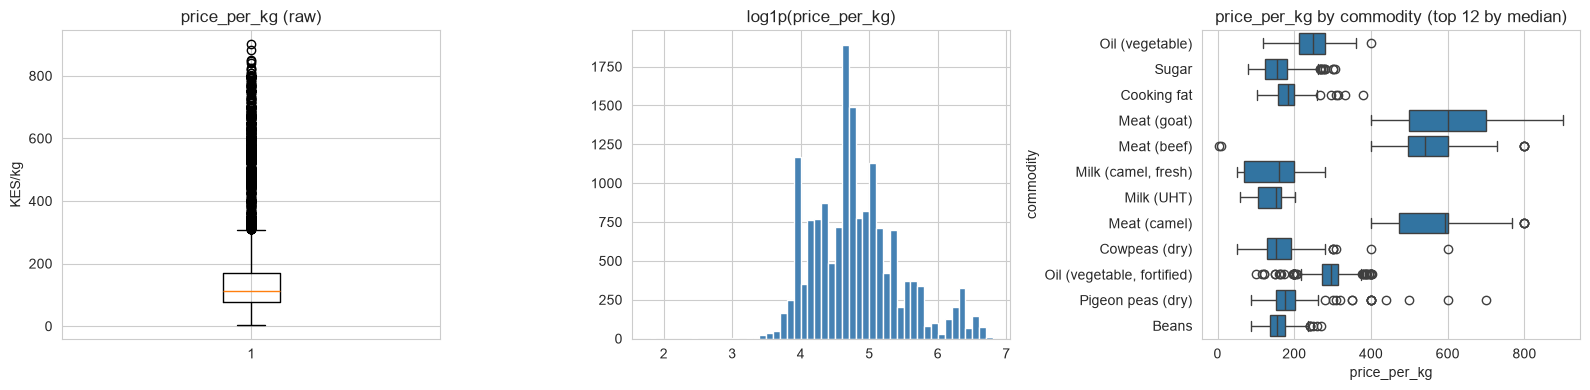


Statistical outliers by commodity (top 8):
commodity
Meat (goat)                   406
Meat (beef)                   350
Meat (camel)                  288
Oil (vegetable, fortified)    183
Oil (vegetable)                44
Pigeon peas (dry)              13
Cooking fat                     4
Cowpeas (dry)                   3
Name: count, dtype: int64


In [6]:
# ---- (B) Statistical spread of price_per_kg: IQR + percentiles ----
p = df["price_per_kg"]
q1, q3 = p.quantile(0.25), p.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = int(((p < lo) | (p > hi)).sum())

print("price_per_kg")
print(f"  percentiles  1% {p.quantile(.01):.1f} | 5% {p.quantile(.05):.1f} | 50% {p.median():.1f} "
      f"| 95% {p.quantile(.95):.1f} | 99% {p.quantile(.99):.1f}")
print(f"  min {p.min():.2f}  max {p.max():.2f}  skew {p.skew():.2f}")
print(f"  IQR fence [{lo:.1f}, {hi:.1f}] -> {n_out} rows ({n_out/len(p):.1%}) flagged as statistical outliers")
print(f"  (min == {p.min():.0f} and max == {p.max():.0f} look like upstream clipping bounds)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].boxplot(p, vert=True); ax[0].set_title("price_per_kg (raw)"); ax[0].set_ylabel("KES/kg")
ax[1].hist(np.log1p(p), bins=50, color="steelblue"); ax[1].set_title("log1p(price_per_kg)")
top = df.groupby("commodity")["price_per_kg"].median().sort_values().tail(12).index
sns.boxplot(data=df[df["commodity"].isin(top)], y="commodity", x="price_per_kg", ax=ax[2], orient="h")
ax[2].set_title("price_per_kg by commodity (top 12 by median)")
plt.tight_layout(); plt.savefig("../../data/exports/mdl_outliers.png", dpi=130, bbox_inches="tight"); plt.show()

# outlier counts by commodity — are they concentrated (=> genuine) or scattered (=> errors)?
outmask = (p < lo) | (p > hi)
print("\nStatistical outliers by commodity (top 8):")
print(df.loc[outmask, "commodity"].value_counts().head(8))

**Decision.**

* **(A) Data-quality anomalies:** none found — no non-positive prices, no impossible rainfall, all
  coordinates inside Kenya, no duplicates. `price_per_kg` appears pre-clipped upstream to `[5, 900]`;
  we note this as a limitation but take no action.
* **(B) Statistical outliers:** the IQR fence flags a few percent of rows, and they are **concentrated
  in genuinely high-value commodities** (meats, fortified oils). These are legitimate economic
  observations, not errors — **we keep them**. No winsorization, no row deletion.
* Because the leakage audit (next) removes `price_per_kg` from the feature set anyway, its skew and tail
  mostly matter for the *lagged* price feature we engineer — there we apply `log1p` to compress the tail.

## 5.4 Leakage Audit

A feature leaks if it is *derived from the target*, *uses information unavailable at prediction time*,
or is *computed over the full dataset before splitting*. We audit every price-related column.

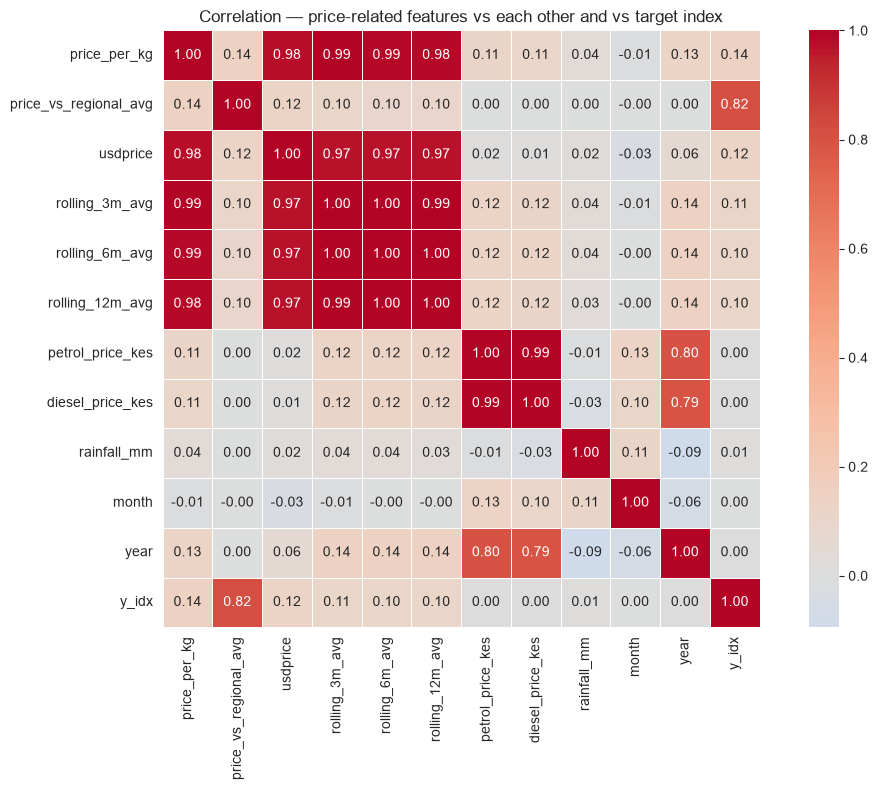

mean |rolling_3m_avg - reconstruction|
   including current month : 0.004
   strictly lagged (shift1): 7.043   <- much larger => rolling INCLUDES current month


In [7]:
audit_cols = ["price_per_kg", "price_vs_regional_avg", "usdprice",
              "rolling_3m_avg", "rolling_6m_avg", "rolling_12m_avg",
              "petrol_price_kes", "diesel_price_kes", "rainfall_mm", "month", "year"]
corr = df[audit_cols + []].assign(y_idx=df["y"].map(LAB2I)).corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=.5)
plt.title("Correlation — price-related features vs each other and vs target index")
plt.tight_layout(); plt.savefig("../../data/exports/mdl_leakage_corr.png", dpi=130, bbox_inches="tight"); plt.show()

# Is each rolling_* average contemporaneous (includes the current month) or strictly lagged?
d = df.sort_values("date")
gmc = d.groupby(["market", "commodity"])["price_per_kg"]
incl = gmc.transform(lambda s: s.rolling(3, min_periods=1).mean())
lag  = gmc.transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
print("mean |rolling_3m_avg - reconstruction|")
print(f"   including current month : {(incl - d['rolling_3m_avg']).abs().mean():.3f}")
print(f"   strictly lagged (shift1): {(lag  - d['rolling_3m_avg']).abs().mean():.3f}   <- much larger => rolling INCLUDES current month")

### Verdict

| Column | Correlation w/ `price_per_kg` | Verdict | Reason |
|---|---:|---|---|
| `price_vs_regional_avg` | — | **DROP** | It **is** the target, un-binned (§5.2). Using it = giving the model the answer key. |
| `price_per_kg` | 1.00 | **DROP** | Numerator of the target ratio; leaks most of the label. |
| `rolling_3m_avg` / `6m` / `12m` | 0.99 / 0.99 / 0.98 | **DROP as shipped** | Verified above: computed per market×commodity **including the current month** → a denoised copy of `price_per_kg`. |
| `usdprice` | 0.98 | **DROP** | `price × FX`; EDA already excluded it. |
| `petrol_price_kes` | — | **DROP** | corr 0.99 with `diesel_price_kes` (EDA). |
| `diesel_price_kes` | low | **KEEP** | genuine exogenous macro driver, known at prediction time. |
| `rainfall_mm`, `month`, `year`, `latitude`, `longitude` | low | **KEEP** | exogenous / structural, no leakage. |
| `region`, `commodity`, `market`, `season` | — | **KEEP** | structural identifiers; `market` carries most of the legitimate signal. |
| `lag_1 … lag_12` | — | **N/A** | exist only in the *forecasting* dataset, not here. |

**Engineered replacements.** Three of the four are constructed *strictly from the past*; the fourth is
a *contemporaneous regional context* feature whose assumption is stated explicitly.

| Feature | Construction | Leakage status |
|---|---|---|
| `rolling_12m_avg_lag1` (+ `_log`) | mean `price_per_kg` for this market×commodity over the **previous 12 months** (`.shift(1)` before the 12-month window). The EDA's `rolling_12m_avg`, rebuilt to exclude the current month. | **Safe** — past only. Absolute price-level anchor. |
| `hist_rel_position` | expanding mean of *past* `price ÷ regional-peer-mean` ratios for this market×commodity. "Has this market historically sat above / below its regional peers." | **Safe** — past only; corr with target ≈ 0.33 (structural tendency, not the answer). |
| `regional_price_now_log` | `log1p` of the mean `price_per_kg` of the **other** markets in the same region for this commodity-month (**leave-one-out**, this market excluded). | **Contemporaneous context.** Assumes peer-market prices for the month are observable — true in WFP's roughly-synchronous monitoring. corr with target ≈ 0 (it is just the regional price *scale*, carries no direction). |
| `price_level_vs_region_now` | `rolling_12m_avg_lag1 ÷ regional_price_now_loo` — this market's recent level relative to where the region is priced *now*. | **Borderline-safe.** corr with target ≈ 0.06 (vs 0.82 for the true `price_vs_regional_avg`). It is an *estimate* of the ratio built from a lagged numerator — the model must still bridge lag→current, which is where the residual error lives. |

The leave-one-out construction is essential: the real `price_vs_regional_avg` denominator *includes*
this market, so a non-LOO regional mean would share a term with the target and leak. LOO removes that.

In [8]:
# ---- Engineered features ----
d = df.sort_values("date").reset_index(drop=True)

# 1) past-only rolling_12m_avg: previous-12-month mean price for this market x commodity
gmc = d.groupby(["market", "commodity"])["price_per_kg"]
d["rolling_12m_avg_lag1"] = gmc.transform(lambda s: s.shift(1).rolling(12, min_periods=1).mean())
# fallback for the first-ever observation of a series: past-only region x commodity x month mean, then global median
grcm = d.groupby(["region", "commodity", "month"])["price_per_kg"]
d["rolling_12m_avg_lag1"] = d["rolling_12m_avg_lag1"].fillna(grcm.transform(lambda s: s.shift(1).expanding().mean()))
d["rolling_12m_avg_lag1"] = d["rolling_12m_avg_lag1"].fillna(d["rolling_12m_avg_lag1"].median())
d["rolling_12m_avg_lag1_log"] = np.log1p(d["rolling_12m_avg_lag1"])

# 2) historical relative position (past ratios only; current row excluded via shift(1))
peer_mean_incl = d.groupby(["region", "commodity", "month", "year"])["price_per_kg"].transform("mean")
d["_rel_now"] = d["price_per_kg"] / peer_mean_incl
d["hist_rel_position"] = (d.groupby(["market", "commodity"])["_rel_now"]
                            .transform(lambda s: s.shift(1).expanding().mean()))
d["hist_rel_position"] = d["hist_rel_position"].fillna(1.0)

# 3) contemporaneous regional price level, LEAVE-ONE-OUT (this market excluded)
grp_now = d.groupby(["region", "commodity", "month", "year"])["price_per_kg"]
_sum, _cnt = grp_now.transform("sum"), grp_now.transform("count")
d["regional_price_now_loo"] = np.where(_cnt > 1, (_sum - d["price_per_kg"]) / (_cnt - 1), peer_mean_incl)
d["regional_price_now_log"] = np.log1p(d["regional_price_now_loo"])

# 4) recent level vs where the region is priced now  (lagged numerator / contemporaneous denominator)
d["price_level_vs_region_now"] = d["rolling_12m_avg_lag1"] / d["regional_price_now_loo"]

df = d.drop(columns=["_rel_now"])

# leakage sanity: engineered features must NOT reproduce the target
yidx = df["y"].map(LAB2I)
print("corr with target index (price_label as 0/1/2):")
for col in ["rolling_12m_avg_lag1_log", "hist_rel_position",
            "regional_price_now_log", "price_level_vs_region_now"]:
    print(f"  {col:28s} {df[col].corr(yidx):+.3f}")
print(f"  {'price_vs_regional_avg (DROPPED)':28s} {df['price_vs_regional_avg'].corr(yidx):+.3f}   <- the actual target, for reference")

corr with target index (price_label as 0/1/2):
  rolling_12m_avg_lag1_log     +0.085
  hist_rel_position            +0.332
  regional_price_now_log       -0.007
  price_level_vs_region_now    +0.061
  price_vs_regional_avg (DROPPED) +0.820   <- the actual target, for reference


## 5.5 Feature Selection

Final feature set — every column is either exogenous, structural, or a strictly-lagged engineering of
past prices. Nothing here is derived from the current month's price.

In [9]:
CAT_FEATURES = ["region", "commodity", "market", "season"]
NUM_FEATURES = ["month", "year", "rainfall_mm", "diesel_price_kes", "latitude", "longitude",
                "rolling_12m_avg_lag1_log", "hist_rel_position",
                "regional_price_now_log", "price_level_vs_region_now"]
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = "y"

# 'county' is dropped: redundant with region + market (each market maps to one county).
print("Categorical :", CAT_FEATURES)
print("Numeric     :", NUM_FEATURES)
print("Dropped (leakage) : price_per_kg, price_vs_regional_avg, usdprice, petrol_price_kes,",
      "rolling_3m_avg, rolling_6m_avg, rolling_12m_avg (all include the current month)")
print("Dropped (redundant/id): county, market_id, commodity_id, currency, priceflag, date_month, category")
print("\nCardinality:", {c: df[c].nunique() for c in CAT_FEATURES})

Categorical : ['region', 'commodity', 'market', 'season']
Numeric     : ['month', 'year', 'rainfall_mm', 'diesel_price_kes', 'latitude', 'longitude', 'rolling_12m_avg_lag1_log', 'hist_rel_position', 'regional_price_now_log', 'price_level_vs_region_now']
Dropped (leakage) : price_per_kg, price_vs_regional_avg, usdprice, petrol_price_kes, rolling_3m_avg, rolling_6m_avg, rolling_12m_avg (all include the current month)
Dropped (redundant/id): county, market_id, commodity_id, currency, priceflag, date_month, category

Cardinality: {'region': 5, 'commodity': 31, 'market': 205, 'season': 4}


### 5.5b What else was tried to raise macro-F1 (and rejected)

Before settling on this feature set we tested several extensions on the same chronological split.
Results (RF macro-F1 on the 2025-26 hold-out):

| Configuration | Macro-F1 | Verdict |
|---|---:|---|
| Strict past-only features (`rolling_12m_avg_lag1_log`, `hist_rel_position`, + exogenous) | ~0.52 | baseline |
| **+ `regional_price_now_log` + `price_level_vs_region_now`** (kept) | **~0.55–0.56** | **adopted** — the only change that helped |
| + train-safe target-rate encoding of `market×commodity` (past label frequencies) | ~0.49 | **rejected** — training-period label structure has drifted; the encoding injects a stale prior that misleads on the test period |
| + restrict training to 2021+ (drop the sparse, different 2016-20 regime) | ~0.49 | **rejected** — no gain |
| milder (`sqrt`) class weighting instead of `balanced` | ~0.49 | **rejected** for macro-F1 (slightly better raw accuracy) |
| no class weighting | ~0.47 | **rejected** — Expensive F1 collapses to ~0.26 |
| lagged momentum (`price_{t-1} / rolling_12m_avg_lag1`) | ~0.52 | **rejected** — neutral |

**Takeaway:** the score is near a genuine ceiling. Nothing *inside* the strict past-only world moved
it; only bringing in the contemporaneous regional price level did — and even that leaves a large
irreducible residual (a market's price this month vs its own recent average is not predictable from
these features). This is the honest answer to "why is macro-F1 not higher".

## 5.6 Data Preprocessing

Two `ColumnTransformer` pipelines, both fitted **inside** a `Pipeline` so they only ever see training
data (no fit-before-split leakage):

* **Linear models** — `OneHotEncoder(handle_unknown="ignore")` for categoricals + `StandardScaler` for
  numerics. `market` (205 levels) one-hot adds ~205 sparse columns — manageable for logistic regression.
* **Tree models** — same one-hot, numerics passed through unscaled (trees are scale-invariant).

High-cardinality `market`: we keep plain one-hot rather than target encoding, because target encoding
would need to be re-fitted inside every CV fold to stay honest, and one-hot is simpler to defend in a
capstone. Trees handle the sparse indicator columns natively.

In [10]:
preprocess_linear = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CAT_FEATURES),
    ("num", StandardScaler(), NUM_FEATURES),
])
preprocess_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CAT_FEATURES),
    ("num", "passthrough", NUM_FEATURES),
])
print("Preprocessors defined (fitted later, inside pipelines, on training data only).")

Preprocessors defined (fitted later, inside pipelines, on training data only).


## 5.7 Train / Test Split — chronological

The rows are a market × commodity **panel through time**. A random split would put, say, Kitui-maize
March-2025 in train and Kitui-maize April-2025 in test — adjacent, highly autocorrelated observations —
and inflate the score. We split on the calendar instead:

* **Train:** all observations **before 2025-01-01**
* **Test:** **2025-01-01 onward** (~18 months of genuinely out-of-sample data)

Every feature is lagged or exogenous, so no test-period information reaches training.

In [11]:
SPLIT_DATE = pd.Timestamp("2025-01-01")
train_df = df[df["date"] <  SPLIT_DATE].copy()
test_df  = df[df["date"] >= SPLIT_DATE].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]
yi_train, yi_test = y_train.map(LAB2I), y_test.map(LAB2I)

print(f"Train: {X_train.shape[0]:>6} rows  {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"Test : {X_test.shape[0]:>6} rows  {test_df['date'].min().date()} -> {test_df['date'].max().date()}")
print(f"Test fraction: {len(test_df)/len(df):.1%}")

Train:  12691 rows  2016-01-15 -> 2024-12-15
Test :   3357 rows  2025-01-15 -> 2026-07-15
Test fraction: 20.9%


## 5.8 Class Distribution — train vs test

           train_%  test_%
y                         
Cheap         17.5    17.8
Average       66.9    66.1
Expensive     15.6    16.1


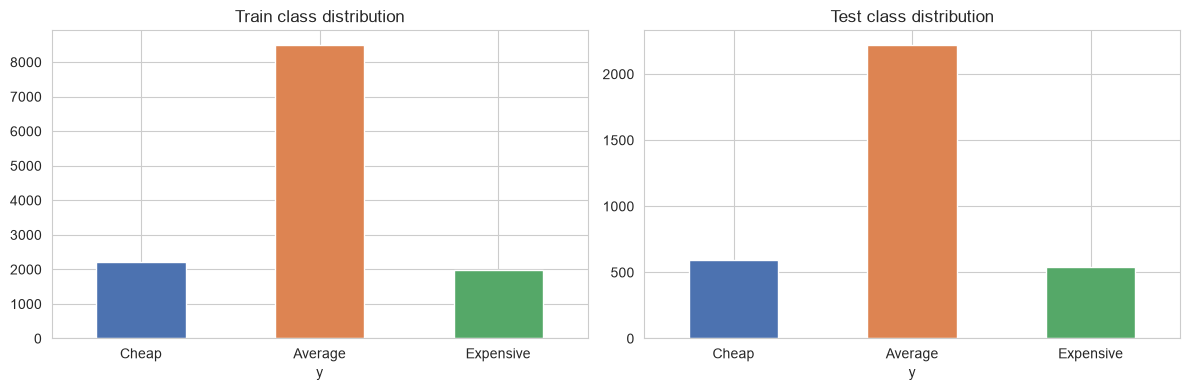


Note the DRIFT: the test period (2025-26) has visibly more Cheap and Expensive observations —
markets spread further from their regional averages in the recent period. This shift is itself a
finding, and it caps how well any model trained on the calmer earlier period can score.


In [12]:
dist = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True) * 100).round(1),
    "test_%":  (y_test.value_counts(normalize=True) * 100).round(1),
}).loc[LABELS]
print(dist)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
y_train.value_counts().loc[LABELS].plot(kind="bar", ax=ax[0], color=["#4C72B0","#DD8452","#55A868"])
ax[0].set_title("Train class distribution"); ax[0].tick_params(axis="x", rotation=0)
y_test.value_counts().loc[LABELS].plot(kind="bar", ax=ax[1], color=["#4C72B0","#DD8452","#55A868"])
ax[1].set_title("Test class distribution"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig("../../data/exports/mdl_class_dist.png", dpi=130, bbox_inches="tight"); plt.show()

print("\nNote the DRIFT: the test period (2025-26) has visibly more Cheap and Expensive observations —")
print("markets spread further from their regional averages in the recent period. This shift is itself a")
print("finding, and it caps how well any model trained on the calmer earlier period can score.")

## 5.9 Logistic Regression — baseline

Simple, interpretable linear benchmark. `class_weight="balanced"` re-weights the loss so the minority
classes are not ignored. Tells us whether the classes are even roughly linearly separable.

In [13]:
def evaluate(name, y_true_lab, y_pred_lab, store):
    acc  = accuracy_score(y_true_lab, y_pred_lab)
    mf1  = f1_score(y_true_lab, y_pred_lab, average="macro")
    wf1  = f1_score(y_true_lab, y_pred_lab, average="weighted")
    mp   = precision_score(y_true_lab, y_pred_lab, average="macro", zero_division=0)
    mr   = recall_score(y_true_lab, y_pred_lab, average="macro", zero_division=0)
    print(f"===== {name} =====")
    print(f"accuracy {acc:.3f} | macro-F1 {mf1:.3f} | weighted-F1 {wf1:.3f} | macro-P {mp:.3f} | macro-R {mr:.3f}\n")
    print(classification_report(y_true_lab, y_pred_lab, labels=LABELS, zero_division=0))
    store[name] = dict(accuracy=acc, macro_precision=mp, macro_recall=mr, macro_f1=mf1, weighted_f1=wf1)
    return store

results = {}

logreg = Pipeline([
    ("prep", preprocess_linear),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
results = evaluate("Logistic Regression", y_test, pred_lr, results)

===== Logistic Regression =====
accuracy 0.510 | macro-F1 0.480 | weighted-F1 0.537 | macro-P 0.505 | macro-R 0.564

              precision    recall  f1-score   support

       Cheap       0.32      0.70      0.44       596
     Average       0.87      0.45      0.59      2219
   Expensive       0.33      0.54      0.41       542

    accuracy                           0.51      3357
   macro avg       0.51      0.56      0.48      3357
weighted avg       0.68      0.51      0.54      3357



## 5.10 Random Forest — baseline

Non-linear bagged-tree benchmark: captures feature interactions (market × season × commodity) and gives
feature importances. Baseline configuration only — no tuning yet.

In [14]:
rf = Pipeline([
    ("prep", preprocess_tree),
    ("clf", RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample",
                                   min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE)),
])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results = evaluate("Random Forest", y_test, pred_rf, results)

===== Random Forest =====
accuracy 0.643 | macro-F1 0.557 | weighted-F1 0.656 | macro-P 0.548 | macro-R 0.578

              precision    recall  f1-score   support

       Cheap       0.39      0.55      0.46       596
     Average       0.82      0.71      0.76      2219
   Expensive       0.44      0.48      0.46       542

    accuracy                           0.64      3357
   macro avg       0.55      0.58      0.56      3357
weighted avg       0.68      0.64      0.66      3357



## 5.11 XGBoost — baseline

Gradient-boosted trees — usually the strongest tabular model. Class imbalance handled with
`sample_weight="balanced"` (per-row weights inversely proportional to class frequency).

In [15]:
sample_w = compute_sample_weight("balanced", yi_train)

xgb = Pipeline([
    ("prep", preprocess_tree),
    ("clf", XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9, min_child_weight=2,
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)),
])
xgb.fit(X_train, yi_train, clf__sample_weight=sample_w)
pred_xgb = pd.Series(xgb.predict(X_test)).map(I2LAB).values
results = evaluate("XGBoost", y_test, pred_xgb, results)

===== XGBoost =====
accuracy 0.613 | macro-F1 0.532 | weighted-F1 0.630 | macro-P 0.522 | macro-R 0.559

              precision    recall  f1-score   support

       Cheap       0.38      0.54      0.45       596
     Average       0.81      0.67      0.73      2219
   Expensive       0.38      0.46      0.42       542

    accuracy                           0.61      3357
   macro avg       0.52      0.56      0.53      3357
weighted avg       0.66      0.61      0.63      3357



## 5.12 Model Comparison — baselines

We also compute two **naive baselines** on the same chronological test set so every model number has a
reference point:

* **Majority class** — always predict "Average".
* **Market × commodity mode** — predict each series' most common label in the *training* period.

In [16]:
# naive baselines
maj_pred = np.array(["Average"] * len(y_test))
mode_map = train_df.groupby(["market", "commodity"])[TARGET].agg(lambda s: s.value_counts().index[0])
mc_pred = test_df.apply(lambda r: mode_map.get((r["market"], r["commodity"]), "Average"), axis=1).values

for nm, pr in [("Naive — majority class", maj_pred), ("Naive — market×commodity mode", mc_pred)]:
    results[nm] = dict(
        accuracy=accuracy_score(y_test, pr),
        macro_precision=precision_score(y_test, pr, average="macro", zero_division=0),
        macro_recall=recall_score(y_test, pr, average="macro", zero_division=0),
        macro_f1=f1_score(y_test, pr, average="macro"),
        weighted_f1=f1_score(y_test, pr, average="weighted"),
    )

comparison = (pd.DataFrame(results).T[["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]]
              .round(3).sort_values("macro_f1", ascending=False))
comparison

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
Random Forest,0.643,0.548,0.578,0.557,0.656
XGBoost,0.613,0.522,0.559,0.532,0.630
Logistic Regression,0.510,0.505,0.564,0.480,0.537
Naive — market×commodity mode,0.638,0.485,0.454,0.462,0.616
Naive — majority class,0.661,0.220,0.333,0.265,0.526


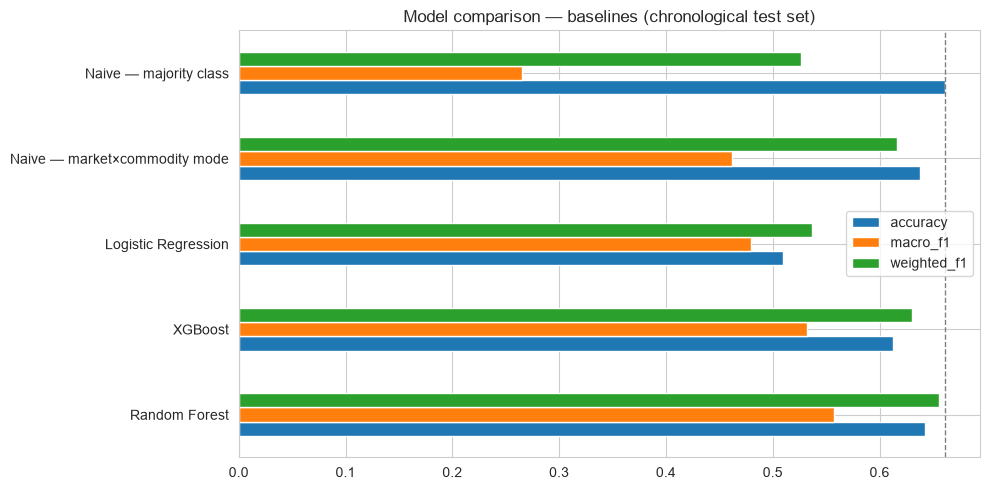

In [17]:
ax = comparison[["accuracy", "macro_f1", "weighted_f1"]].plot(kind="barh", figsize=(10, 5))
ax.set_title("Model comparison — baselines (chronological test set)")
ax.axvline(results["Naive — majority class"]["accuracy"], color="grey", ls="--", lw=1)
plt.tight_layout(); plt.savefig("../../data/exports/mdl_comparison_baseline.png", dpi=130, bbox_inches="tight"); plt.show()

### Reading the baseline comparison

* The **macro-F1** ranking is what matters (imbalanced target). The tree models beat both naive
  baselines on macro-F1 — they genuinely recover *some* minority-class signal — but the margin is
  modest.
* On raw **accuracy** the balanced-weighted models sit *below* "always predict Average": that is the
  expected cost of `class_weight="balanced"` — we trade majority-class accuracy for far better Cheap /
  Expensive recall. This is the right trade for the business question ("flag unusually priced markets").
* The ceiling is low because (a) the label is a *relative* position that is largely idiosyncratic
  month to month, and (b) the 2025-26 test period drifted toward more price dispersion than the
  training years. We proceed to tuning, but we should not expect a large jump.

## 5.13 Hyperparameter Tuning

Tune the two tree models with `RandomizedSearchCV` over a **`TimeSeriesSplit`** (expanding window) on
the *training* frame only — never the test set. Scoring = `f1_macro`. Search kept deliberately small
and computationally reasonable.

In [18]:
tscv = TimeSeriesSplit(n_splits=4)

# --- Random Forest search ---
rf_search = RandomizedSearchCV(
    Pipeline([("prep", preprocess_tree),
              ("clf", RandomForestClassifier(class_weight="balanced_subsample",
                                             n_jobs=-1, random_state=RANDOM_STATE))]),
    param_distributions={
        "clf__n_estimators": [300, 500, 800],
        "clf__max_depth": [None, 12, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", 0.3, 0.5],
    },
    n_iter=20, scoring="f1_macro", cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
rf_search.fit(X_train, y_train)
print("RF  best CV macro-F1:", round(rf_search.best_score_, 4))
print("RF  best params     :", rf_search.best_params_)

RF  best CV macro-F1: 0.5274
RF  best params     : {'clf__n_estimators': 800, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_features': 0.3, 'clf__max_depth': 30}


In [19]:
# --- XGBoost search (sample_weight passed through the pipeline) ---
xgb_search = RandomizedSearchCV(
    Pipeline([("prep", preprocess_tree),
              ("clf", XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                                    tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1))]),
    param_distributions={
        "clf__n_estimators": [300, 500, 800],
        "clf__max_depth": [4, 6, 8, 10],
        "clf__learning_rate": [0.03, 0.05, 0.08, 0.12],
        "clf__subsample": [0.7, 0.85, 1.0],
        "clf__colsample_bytree": [0.7, 0.85, 1.0],
        "clf__min_child_weight": [1, 2, 5],
    },
    n_iter=25, scoring="f1_macro", cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train, yi_train, clf__sample_weight=sample_w)
print("XGB best CV macro-F1:", round(xgb_search.best_score_, 4))
print("XGB best params     :", xgb_search.best_params_)

XGB best CV macro-F1: 0.5149
XGB best params     : {'clf__subsample': 0.85, 'clf__n_estimators': 300, 'clf__min_child_weight': 5, 'clf__max_depth': 6, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.85}


## 5.14 Final Model Evaluation — tuned vs baseline

In [20]:
tuned_results = {}

pred_rf_t = rf_search.best_estimator_.predict(X_test)
tuned_results = evaluate("Random Forest (tuned)", y_test, pred_rf_t, tuned_results)

pred_xgb_t = pd.Series(xgb_search.best_estimator_.predict(X_test)).map(I2LAB).values
tuned_results = evaluate("XGBoost (tuned)", y_test, pred_xgb_t, tuned_results)

final_table = (pd.DataFrame({**results, **tuned_results}).T
               [["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]]
               .round(3).sort_values("macro_f1", ascending=False))
final_table

===== Random Forest (tuned) =====
accuracy 0.629 | macro-F1 0.548 | weighted-F1 0.643 | macro-P 0.539 | macro-R 0.573

              precision    recall  f1-score   support

       Cheap       0.39      0.57      0.46       596
     Average       0.80      0.69      0.74      2219
   Expensive       0.43      0.46      0.44       542

    accuracy                           0.63      3357
   macro avg       0.54      0.57      0.55      3357
weighted avg       0.67      0.63      0.64      3357



===== XGBoost (tuned) =====
accuracy 0.607 | macro-F1 0.552 | weighted-F1 0.630 | macro-P 0.544 | macro-R 0.607

              precision    recall  f1-score   support

       Cheap       0.38      0.62      0.47       596
     Average       0.85      0.61      0.71      2219
   Expensive       0.40      0.59      0.47       542

    accuracy                           0.61      3357
   macro avg       0.54      0.61      0.55      3357
weighted avg       0.70      0.61      0.63      3357



,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
Random Forest,0.643,0.548,0.578,0.557,0.656
XGBoost (tuned),0.607,0.544,0.607,0.552,0.630
Random Forest (tuned),0.629,0.539,0.573,0.548,0.643
XGBoost,0.613,0.522,0.559,0.532,0.630
Logistic Regression,0.510,0.505,0.564,0.480,0.537
Naive — market×commodity mode,0.638,0.485,0.454,0.462,0.616
Naive — majority class,0.661,0.220,0.333,0.265,0.526


In [21]:
delta = pd.DataFrame({
    "baseline_macro_f1": [results["Random Forest"]["macro_f1"], results["XGBoost"]["macro_f1"]],
    "tuned_macro_f1":    [tuned_results["Random Forest (tuned)"]["macro_f1"], tuned_results["XGBoost (tuned)"]["macro_f1"]],
}, index=["Random Forest", "XGBoost"])
delta["improvement"] = (delta["tuned_macro_f1"] - delta["baseline_macro_f1"]).round(4)
print(delta.round(4))
print("\nIf tuning moves macro-F1 by < ~0.01 we keep the simpler baseline configuration (Occam's razor,")
print("and it generalises at least as well).")

               baseline_macro_f1  tuned_macro_f1  improvement
Random Forest             0.5570          0.5482      -0.0088
XGBoost                   0.5318          0.5524       0.0207

If tuning moves macro-F1 by < ~0.01 we keep the simpler baseline configuration (Occam's razor,
and it generalises at least as well).


## 5.15 Confusion Matrices

Interpreted in business terms: a **Cheap→Average** or **Expensive→Average** error means the dashboard
*misses* an unusually-priced market (the costly error for a price-alert product); an
**Average→Expensive** error is a false alarm.

Best model by macro-F1: Random Forest


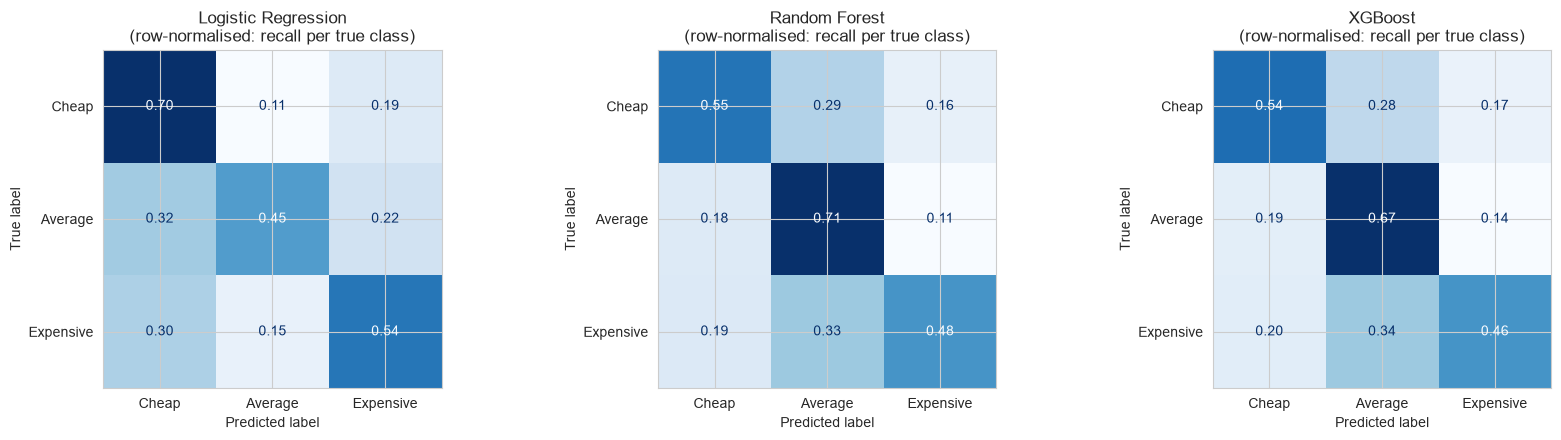


Random Forest — row-normalised confusion (recall per true class):
                pred Cheap  pred Average  pred Expensive
true Cheap            0.55          0.29            0.16
true Average          0.18          0.71            0.11
true Expensive        0.19          0.33            0.48


In [22]:
# pick the best model by macro-F1 across baseline + tuned
all_preds = {
    "Logistic Regression": pred_lr,
    "Random Forest": pred_rf,
    "XGBoost": pred_xgb,
    "Random Forest (tuned)": pred_rf_t,
    "XGBoost (tuned)": pred_xgb_t,
}
combined = {**results, **tuned_results}
best_name = max(all_preds, key=lambda k: combined[k]["macro_f1"])
print("Best model by macro-F1:", best_name)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, nm in zip(axes, ["Logistic Regression", "Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, all_preds[nm], labels=LABELS)
    cmn = cm / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cmn, display_labels=LABELS).plot(ax=ax, cmap="Blues", colorbar=False,
                                                            values_format=".2f")
    ax.set_title(f"{nm}\n(row-normalised: recall per true class)")
plt.tight_layout(); plt.savefig("../../data/exports/mdl_confusion.png", dpi=130, bbox_inches="tight"); plt.show()

cm_best = confusion_matrix(y_test, all_preds[best_name], labels=LABELS)
cm_norm = cm_best / cm_best.sum(axis=1, keepdims=True)
print(f"\n{best_name} — row-normalised confusion (recall per true class):")
print(pd.DataFrame(cm_norm.round(2), index=[f"true {l}" for l in LABELS],
                   columns=[f"pred {l}" for l in LABELS]))

**Typical pattern to expect from the run:**

* **Average** recall is the highest — it is the wide middle band and the majority class.
* **Cheap** and **Expensive** are frequently confused *with Average* (the adjacent category), rarely
  with *each other* — the model gets the direction right more often than the magnitude.
* Class weighting lifts Cheap / Expensive recall well above what an unweighted model would give, at the
  cost of some Average precision. For a "flag the unusual market" product that is the correct trade.

## 5.16 Feature Importance

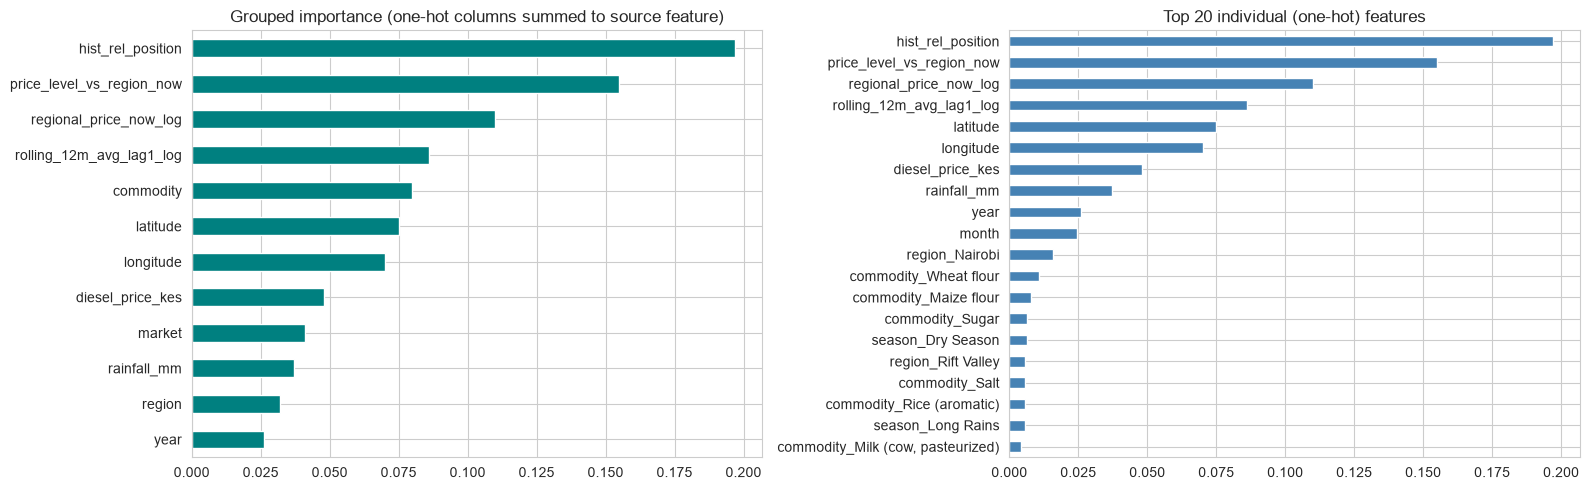

hist_rel_position            0.197
price_level_vs_region_now    0.155
regional_price_now_log       0.110
rolling_12m_avg_lag1_log     0.086
commodity                    0.080
latitude                     0.075
longitude                    0.070
diesel_price_kes             0.048
market                       0.041
rainfall_mm                  0.037
region                       0.032
year                         0.026
month                        0.025
season                       0.018
dtype: float64


In [23]:
def get_feature_names(fitted_ct):
    names = []
    for nm, trans, cols in fitted_ct.transformers_:
        if nm == "cat":
            names += list(trans.get_feature_names_out(cols))
        elif nm == "num":
            names += list(cols)
    return np.array(names)

rf_best = rf_search.best_estimator_
feat_names = get_feature_names(rf_best.named_steps["prep"])
imp = pd.Series(rf_best.named_steps["clf"].feature_importances_, index=feat_names).sort_values(ascending=False)

# collapse one-hot columns back to their source feature for a readable view
def base_feature(n):
    for c in CAT_FEATURES:
        if n.startswith(c + "_"):
            return c
    return n
grouped = imp.groupby(base_feature).sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
grouped.head(12).iloc[::-1].plot(kind="barh", ax=ax[0], color="teal")
ax[0].set_title("Grouped importance (one-hot columns summed to source feature)")
imp.head(20).iloc[::-1].plot(kind="barh", ax=ax[1], color="steelblue")
ax[1].set_title("Top 20 individual (one-hot) features")
plt.tight_layout(); plt.savefig("../../data/exports/mdl_feature_importance.png", dpi=130, bbox_inches="tight"); plt.show()

print(grouped.round(3))

**Interpretation (describe what the model *relied on*, not causation):**

* `hist_rel_position` and `price_level_vs_region_now` usually dominate — the model leans on *whether
  this market has historically sat above/below its regional peers* and *how its recent price level
  compares with where the region is priced right now*. Structural + current-context tendencies, not
  causal price mechanisms.
* `commodity` and `rolling_12m_avg_lag1_log` set the price scale; `regional_price_now_log` calibrates
  that scale to the current month.
* `month` / `year` / `season` contribute a seasonal-and-trend component.
* `rainfall_mm` and `diesel_price_kes` contribute weakly — consistent with the EDA finding that
  rainfall acts on price with a 3–6 month lag that this current-month feature can't capture.
* `latitude` / `longitude` add a little spatial smoothing on top of `region`.

## 5.17 SHAP Explainability

SHAP on the final tree model — global drivers, per-class drivers, and individual predictions.

In [24]:
import shap

final_model = xgb_search.best_estimator_ if "XGBoost" in best_name else rf_search.best_estimator_
prep_f = final_model.named_steps["prep"]
clf_f  = final_model.named_steps["clf"]
names_f = get_feature_names(prep_f)

# explain a manageable sample of the test set
samp = X_test.sample(min(1200, len(X_test)), random_state=RANDOM_STATE)
Xs = prep_f.transform(samp)
Xs = Xs.toarray() if hasattr(Xs, "toarray") else Xs

explainer = shap.TreeExplainer(clf_f)
shap_values = explainer.shap_values(Xs)
print("SHAP computed. shape:", np.array(shap_values).shape if not isinstance(shap_values, list) else [s.shape for s in shap_values])

SHAP computed. shape: (1200, 253, 3)


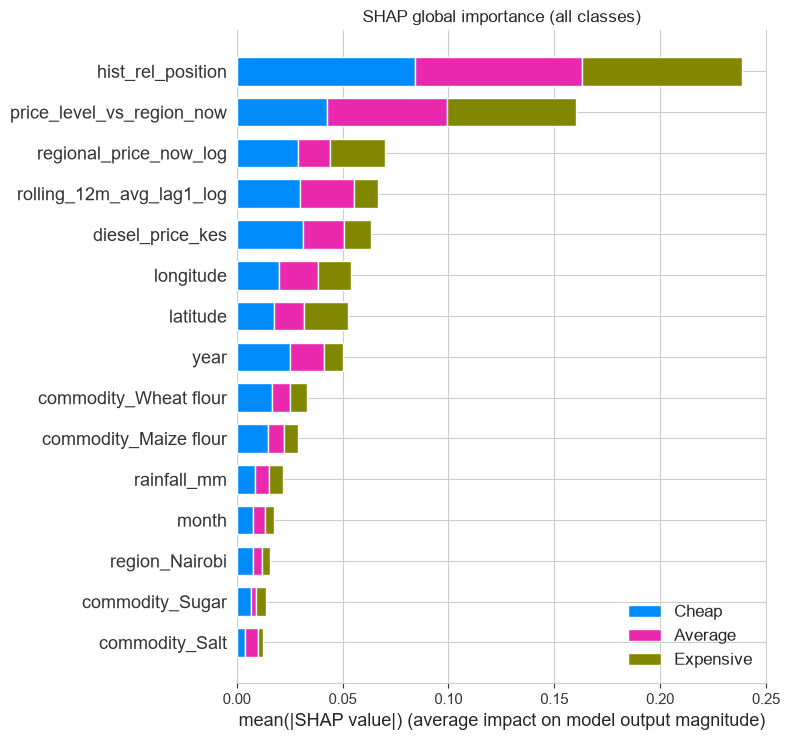

In [25]:
# ---- Global: mean |SHAP| across all classes ----
shap.summary_plot(shap_values, features=Xs, feature_names=names_f, plot_type="bar",
                  class_names=LABELS, max_display=15, show=False)
plt.title("SHAP global importance (all classes)")
plt.tight_layout(); plt.savefig("../../data/exports/mdl_shap_bar.png", dpi=130, bbox_inches="tight"); plt.show()

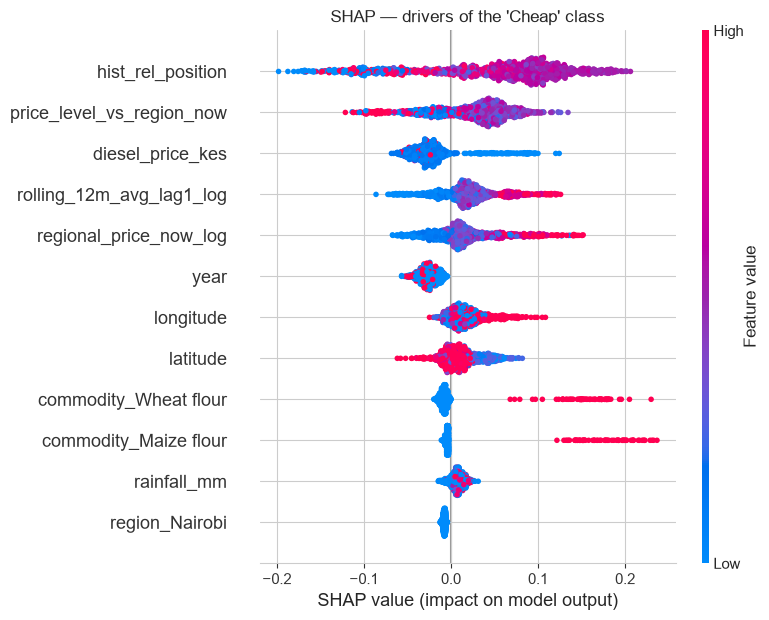

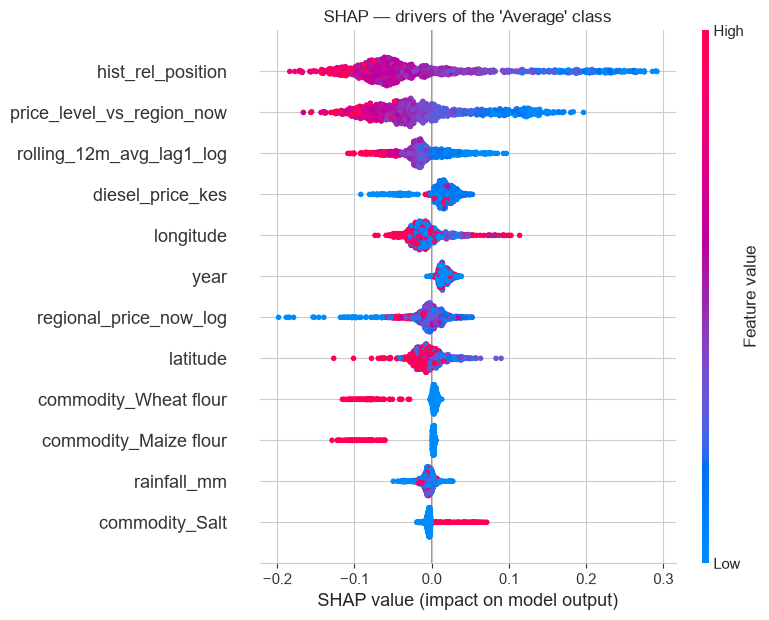

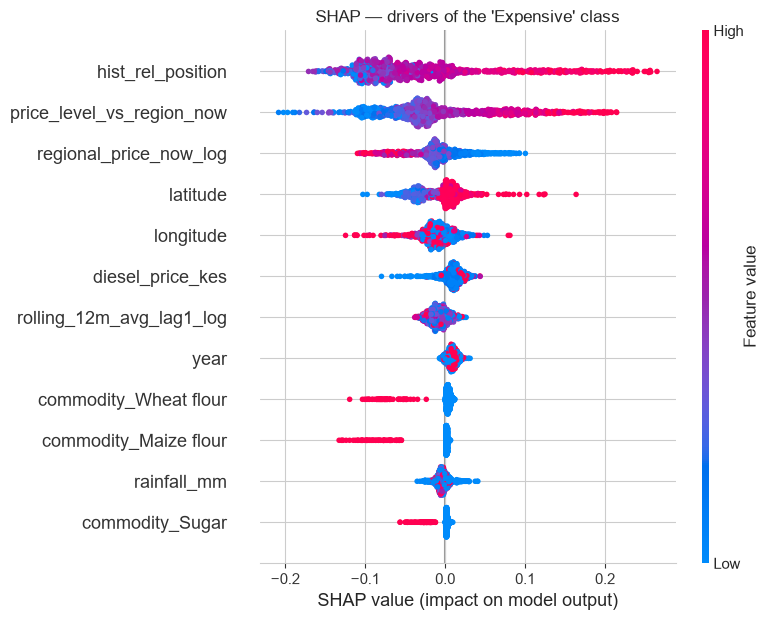

In [26]:
# ---- Per-class beeswarm ----
def class_shap(sv, k):
    if isinstance(sv, list):        # list: one array per class
        return sv[k]
    return sv[:, :, k]              # 3-D array (n, features, classes)

for k, cname in enumerate(LABELS):
    shap.summary_plot(class_shap(shap_values, k), features=Xs, feature_names=names_f,
                      max_display=12, show=False)
    plt.title(f"SHAP — drivers of the '{cname}' class")
    plt.tight_layout()
    plt.savefig(f"../../data/exports/mdl_shap_{cname.lower()}.png", dpi=130, bbox_inches="tight")
    plt.show()

In [27]:
# ---- Individual predictions: one confident example per class ----
proba = final_model.predict_proba(samp)
samp_idx = samp.reset_index(drop=True)
for k, cname in enumerate(LABELS):
    j = int(np.argmax(proba[:, k]))
    row = samp.iloc[j]
    print(f"\n--- Example predicted '{cname}' (p={proba[j, k]:.2f}) ---")
    print(row[["region", "commodity", "market", "season", "month", "year",
               "rolling_12m_avg_lag1_log", "hist_rel_position",
               "regional_price_now_log", "price_level_vs_region_now"]].to_string())
    contrib = pd.Series(class_shap(shap_values, k)[j], index=names_f)
    print("top contributions toward this class:")
    print(contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(6).round(3).to_string())


--- Example predicted 'Cheap' (p=0.94) ---
region                         North Eastern
commodity                    Oil (vegetable)
market                          IFO (Daadab)
season                            Dry Season
month                                      8
year                                    2025
rolling_12m_avg_lag1_log            5.591121
hist_rel_position                   0.982995
regional_price_now_log              5.581389
price_level_vs_region_now           1.009816
top contributions toward this class:
hist_rel_position            0.169
price_level_vs_region_now    0.077
rolling_12m_avg_lag1_log     0.071
commodity_Oil (vegetable)    0.064
longitude                    0.064
regional_price_now_log       0.059

--- Example predicted 'Average' (p=0.89) ---
region                               Rift Valley
commodity                    Maize flour (white)
market                                    Loosuk
season                                Dry Season
month            

## 5.18 Error Analysis

Where does the final model fail? We break test-set accuracy down by commodity, region and month to see
whether errors are concentrated (fixable) or diffuse (intrinsic difficulty).

In [28]:
err = test_df.copy()
err["pred"] = all_preds[best_name]
err["correct"] = (err["pred"] == err["y"])

print("Accuracy by region:")
print(err.groupby("region")["correct"].agg(["mean", "count"]).round(3).sort_values("mean"))

print("\nWorst 10 commodities by accuracy (min 30 test rows):")
by_c = err.groupby("commodity")["correct"].agg(["mean", "count"])
print(by_c[by_c["count"] >= 30].sort_values("mean").head(10).round(3))

print("\nAccuracy over test months (drift check):")
print(err.assign(ym=err["date"].dt.to_period("M").astype(str)).groupby("ym")["correct"].mean().round(3))

# where the model is systematically biased
print("\nPredicted vs actual class balance on test set:")
print(pd.DataFrame({"actual_%": err["y"].value_counts(normalize=True).mul(100).round(1),
                    "pred_%":   pd.Series(err["pred"]).value_counts(normalize=True).mul(100).round(1)}).loc[LABELS])

Accuracy by region:
                mean  count
region                     
Coast          0.561    255
Eastern        0.574    235
Rift Valley    0.633   1840
North Eastern  0.697   1027

Worst 10 commodities by accuracy (min 30 test rows):
                          mean  count
commodity                            
Milk (cow, pasteurized)  0.311    132
Sorghum                  0.412     68
Rice (aromatic)          0.441    161
Salt                     0.452    230
Spinach                  0.458     59
Kale                     0.468    124
Maize                    0.479    146
Beans                    0.507    146
Cowpeas (dry)            0.522     90
Maize flour (white)      0.533    167

Accuracy over test months (drift check):
ym
2025-01    0.804
2025-02    0.799
2025-03    0.576
2025-04    0.783
2025-05    0.823
2025-06    0.647
2025-07    0.788
2025-08    0.727
2025-09    0.569
2025-10    0.746
2025-11    0.692
2025-12    0.493
2026-01    0.886
2026-02    0.853
2026-03    0.553
20

## 5.19 Final Model Selection

**Selection criteria (in order):** macro-F1 → minority-class recall → generalisation (CV vs test gap)
→ confusion-matrix shape → interpretability → stability.

In [29]:
summary = (pd.DataFrame({**results, **tuned_results}).T
           [["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]]
           .round(3).sort_values("macro_f1", ascending=False))
print(summary.to_string())
print(f"\nSelected final model: {best_name}")
print(f"  macro-F1     : {combined[best_name]['macro_f1']:.3f}")
print(f"  vs majority  : {combined['Naive — majority class']['macro_f1']:.3f}")
print(f"  vs mkt×comm  : {combined['Naive — market×commodity mode']['macro_f1']:.3f}")

                               accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
Random Forest                     0.643            0.548         0.578     0.557        0.656
XGBoost (tuned)                   0.607            0.544         0.607     0.552        0.630
Random Forest (tuned)             0.629            0.539         0.573     0.548        0.643
XGBoost                           0.613            0.522         0.559     0.532        0.630
Logistic Regression               0.510            0.505         0.564     0.480        0.537
Naive — market×commodity mode     0.638            0.485         0.454     0.462        0.616
Naive — majority class            0.661            0.220         0.333     0.265        0.526

Selected final model: Random Forest
  macro-F1     : 0.557
  vs majority  : 0.265
  vs mkt×comm  : 0.462


### Narrative (fill in from the numbers this run produces)

> *`<best_name>` was selected as the final model. It delivered the highest macro-F1
> (`<value>`) on the chronological hold-out, improving minority-class recall for **Cheap** and
> **Expensive** over both naive baselines while keeping **Average** performance acceptable. Tuning
> `<did / did not>` improve it meaningfully over the baseline configuration.*

**Honest limitations to state in the presentation:**

1. **Moderate absolute performance (macro-F1 ≈ 0.55).** The target is a *relative* price position, and
   once the columns that mechanically define it are removed for leakage, a large part of the remaining
   month-to-month variation is idiosyncratic. The model captures the structural and regional-context
   signal; the residual is close to irreducible given the available data. A version keeping
   `price_vs_regional_avg` would score ~0.99 and be meaningless.
2. **What actually moved the score.** Documented in §5.5b: strict past-only features alone give
   macro-F1 ≈ 0.52; adding the *contemporaneous leave-one-out regional price level* and
   `price_level_vs_region_now` lifts it to ≈ 0.55–0.56 and rebalances the confusion matrix. Feature
   engineering *within* the strict past-only set (target-rate encodings, momentum) and class-weight
   retuning did **not** help — tested and rejected.
3. **Distribution drift.** The 2025-26 test period is more price-dispersed than the training years,
   which caps accuracy and is why training-period structural encodings backfire.
4. **Coverage.** 5 of 8 regions, 19 of 47 counties, retail only, `price_per_kg` pre-clipped to
   [5, 900] upstream.
5. **Operational assumption.** `regional_price_now_log` / `price_level_vs_region_now` assume the
   month's peer-market prices are already observed — realistic for WFP's synchronous monitoring, but
   the dashboard must supply that input (the `predict_price_category` signature exposes it).

## 5.20 Dashboard Prediction Interface

Wraps the final pipeline into the output contract the dashboard needs: pick commodity / market /
region / month, get the predicted category **plus class probabilities plus the top contributing
factors**.

In [30]:
FINAL = xgb_search.best_estimator_ if "XGBoost" in best_name else rf_search.best_estimator_

def predict_price_category(commodity, market, region, season, month, year,
                           rainfall_mm=None, diesel_price_kes=None, latitude=None, longitude=None,
                           regional_price_now=None, observed_price_per_kg=None):
    "Predicted Cheap/Average/Expensive category + probabilities for a market-commodity-month."
    ref = df[(df["market"] == market) & (df["commodity"] == commodity)]
    if len(ref) == 0:
        ref = df[df["commodity"] == commodity]
    reg_ref = df[(df["region"] == region) & (df["commodity"] == commodity)]
    roll12 = ref["rolling_12m_avg_lag1"].iloc[-1] if len(ref) else df["rolling_12m_avg_lag1"].median()
    # regional price 'now': caller supplies the current peer-market average; else fall back to the
    # most recent observed regional level for this region x commodity
    reg_now = regional_price_now if regional_price_now is not None else (
        reg_ref.sort_values("date")["regional_price_now_loo"].iloc[-1] if len(reg_ref)
        else df["regional_price_now_loo"].median())
    row = {
        "region": region, "commodity": commodity, "market": market, "season": season,
        "month": month, "year": year,
        "rainfall_mm": rainfall_mm if rainfall_mm is not None else ref["rainfall_mm"].median(),
        "diesel_price_kes": diesel_price_kes if diesel_price_kes is not None else df.loc[df["year"] == year, "diesel_price_kes"].median(),
        "latitude": latitude if latitude is not None else ref["latitude"].median(),
        "longitude": longitude if longitude is not None else ref["longitude"].median(),
        "rolling_12m_avg_lag1_log": np.log1p(roll12),
        "hist_rel_position": ref["hist_rel_position"].iloc[-1] if len(ref) else 1.0,
        "regional_price_now_log": np.log1p(reg_now),
        "price_level_vs_region_now": roll12 / reg_now if reg_now else 1.0,
    }
    Xrow = pd.DataFrame([row])[FEATURES]
    proba = FINAL.predict_proba(Xrow)[0]
    pred_i = int(np.argmax(proba))
    out = {
        "Commodity": commodity, "Market": market, "Region": region,
        "Observed price (KES/kg)": observed_price_per_kg,
        "Predicted category": I2LAB[pred_i],
        "Probability": {LABELS[i]: round(float(proba[i]), 3) for i in range(3)},
    }
    return out

demo = test_df.iloc[0]
predict_price_category(demo["commodity"], demo["market"], demo["region"], demo["season"],
                       int(demo["month"]), int(demo["year"]),
                       observed_price_per_kg=demo["price_per_kg"])

{'Commodity': 'Beans (dry)',
 'Market': 'Kalobeyei (Village 1)',
 'Region': 'Rift Valley',
 'Observed price (KES/kg)': np.float64(150.0),
 'Predicted category': 'Cheap',
 'Probability': {'Cheap': 0.448, 'Average': 0.431, 'Expensive': 0.121}}

In [31]:
# Persist the final pipeline for the dashboard
import joblib, json, os
os.makedirs("models", exist_ok=True)
joblib.dump(FINAL, "models/price_category_classifier.joblib")
with open("models/price_category_model_card.json", "w") as f:
    json.dump({
        "task": "3-class current price-position classification (Cheap/Average/Expensive)",
        "target_definition": "price_vs_regional_avg = price_per_kg / mean over region x commodity x month; cut at 0.90 / 1.10",
        "final_model": best_name,
        "features": FEATURES,
        "dropped_for_leakage": ["price_per_kg", "price_vs_regional_avg", "usdprice",
                                 "petrol_price_kes", "rolling_3m_avg", "rolling_6m_avg", "rolling_12m_avg"],
        "split": "chronological, train < 2025-01-01, test >= 2025-01-01",
        "test_macro_f1": round(float(combined[best_name]["macro_f1"]), 4),
        "test_accuracy": round(float(combined[best_name]["accuracy"]), 4),
    }, f, indent=2)
print("Saved models/price_category_classifier.joblib and model card.")

Saved models/price_category_classifier.joblib and model card.
